# 01 - Image Basics

## Imports

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Make sure we get outputs from a probabilitistic model each time (for reproducibility) 
np.random.seed(1515)

## What is an Image? 

### Computer vs. Human Interpretation

This might sound like a pretty weird question, considering we all know what an image is. It is a visual representation of, well, anything! 

But that's how *we* see images. How do computers see images? 

Computers are able to interpret images because images are grids of pixels. A pixel is the smallest unit of an image - it is a tiny dot/square that represents a color that we see on the screen.

### Images are Grids of Pixels

So, what do these grids actually look like. Well, it depends on if your image has color or not. 

Note that for the sake of the following examples, note we are going to be referring to 8-bit images, which means that our pixel values can range from 0-255. These values represent the intensity of the color.

Let's start with the more simple example, a grayscale image (black and white).

#### Grayscale Images

A grasycale image is a 2D grid, meaning that it has a height and width dimension, or $H \times W$. Each value is assigned 0-255, as mentioned above, and feeding these values in allows us to render an image. 

We create an example image with a bright square in the middle below: 

Shape: (6, 10)
Data type: uint8
[[  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 200 200 200 200   0   0   0]
 [  0   0   0 200 200 200 200   0   0   0]
 [  0   0   0 200 200 200 200   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]]


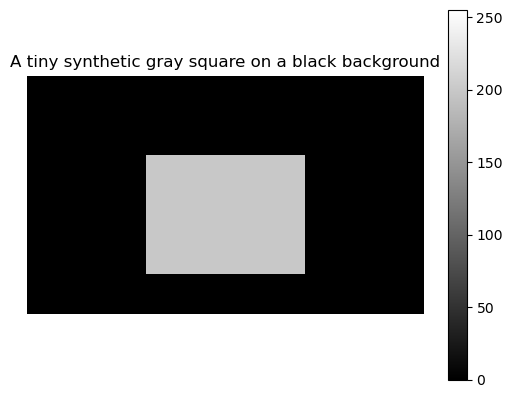

In [27]:
img_gray = np.zeros((6, 10), dtype=np.uint8)  # 6 rows (height), 10 cols (width) --> each pixel = 0 (black) 
img_gray[2:5, 3:7] = 200  # a bright block (all pixels = 200)

print("Shape:", img_gray.shape)
print("Data type:", img_gray.dtype)
print(img_gray)

plt.figure()
plt.title("A tiny synthetic gray square on a black background")
plt.imshow(img_gray, cmap="gray", vmin=0, vmax=255)
plt.colorbar()
plt.axis("off");

So, we see that with the grayscale images, the color intensity is adjusting how black/white an image is. 

What if we want to have color?

### Color Images

For color, we need to add color channels so we can create the color representation. So, we have a new grid representation to deal with. Insted of $H \times W$, we have $H \times W \times (RGB)$, where $RGB$ stands for Red, Blue, Green. RGB is a very common color channel because these colors can easily combine to form different colors that we would see in images. 

Let's look at how this looks in code: 

Shape: (60, 120, 3)
Pixel at (10,10): [255   0   0]
Pixel at (30,10): [  0 255   0]
Pixel at (50,10): [  0   0 255]


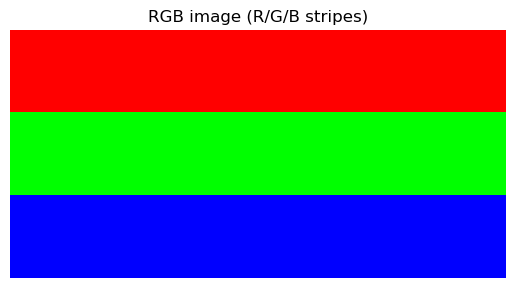

In [9]:
img_rgb = np.zeros((60, 120, 3), dtype=np.uint8)

# Red stripe (top third)
img_rgb[0:20, :, 0] = 255  # R channel

# Green stripe (middle third)
img_rgb[20:40, :, 1] = 255  # G channel

# Blue stripe (bottom third)
img_rgb[40:60, :, 2] = 255  # B channel

print("Shape:", img_rgb.shape)  # (height, width, channels)
print("Pixel at (10,10):", img_rgb[10,10])  # [255,0,0]
print("Pixel at (30,10):", img_rgb[30,10])  # [0,255,0]
print("Pixel at (50,10):", img_rgb[50,10])  # [0,0,255]

plt.figure()
plt.title("RGB image (R/G/B stripes)")
plt.imshow(img_rgb)
plt.axis("off");

We can break this off into its distinct parts to show how each color channel is its own 2D grid of pixels that show the most intensity where the color is (a white stripe), and the least intensity where there is no sign of that color (black):

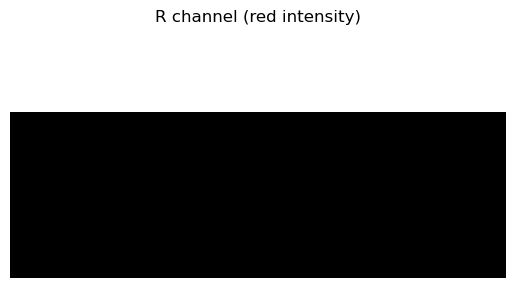

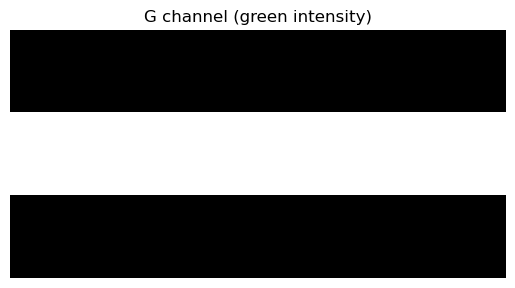

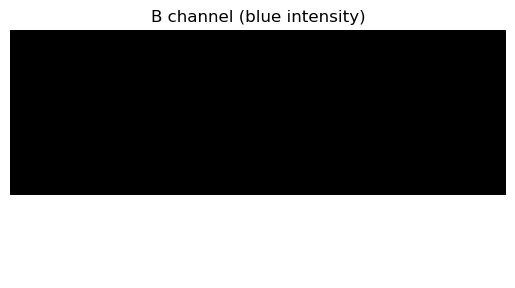

In [15]:
R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

plt.figure()
plt.title("R channel (red intensity)")
plt.imshow(R, cmap="gray", vmin=0, vmax=255)
plt.axis("off");

plt.figure()
plt.title("G channel (green intensity)")
plt.imshow(G, cmap="gray", vmin=0, vmax=255)
plt.axis("off");

plt.figure()
plt.title("B channel (blue intensity)")
plt.imshow(B, cmap="gray", vmin=0, vmax=255)
plt.axis("off");

### Coordinate Systems

As a quick aside, it is important to note that when using the `NumPy` package in python, that our coordinate system is a little bit different than the usual math notation.
- `img[row, col]` → `img[y, x]` (row is **y**, column is **x**)
- The origin `(0,0)` is the **top-left**, so y increases *downward*

This is just to avoid any confusion when we are dealing with the image grid. 